In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Seed
random.seed(42)
np.random.seed(42)

In [3]:
# Global variables
CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'time_series', 'real', 'ECL')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints''time_series', 'real', 'ECL')
OUT_PATH = os.path.join(CURRENT_DIR, 'out' 'time_series', 'real', 'ECL')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

# Show info on the terminal about how the execution is going.
VERBOSE = True
# Even if there is a checkpoint, the model is retrained.
FORCE_TRAINING = True
# Name of this experiment that will appear in the result files.
SUBFIX_NAME = 'gradient'

In [4]:
df_data = pd.read_csv(os.path.join(DATA_PATH, 'ECL.csv'))
df_data.shape

(26304, 322)

In [5]:
df_data.describe().T

,count,mean,std,min,25%,50%,75%,max
MT_000,26304.0,23.263762,24.127164,0.0,9.00,11.0,24.0,140.0
MT_001,26304.0,112.885569,25.553141,0.0,95.00,113.0,130.0,296.0
MT_002,26304.0,16.821624,49.190377,0.0,8.00,8.0,10.0,601.0
MT_003,26304.0,440.335196,152.601050,0.0,334.75,400.0,511.0,1170.0
MT_004,26304.0,200.536724,69.727348,0.0,148.00,190.0,239.0,547.0
...,...,...,...,...,...,...,...,...
MT_316,26304.0,350.702137,241.241444,0.0,94.00,361.0,505.0,1330.0
MT_317,26304.0,51.490344,37.228837,0.0,27.00,37.0,57.0,205.0
MT_318,26304.0,2264.188641,545.279372,0.0,1999.00,2319.0,2607.0,4449.0
MT_319,26304.0,507.008858,267.445473,0.0,233.00,504.0,704.0,1369.0


In [6]:
df_data['date'] = pd.to_datetime(df_data['date'])

In [7]:
df_data.nunique()

date      26304
MT_000      122
MT_001      207
MT_002      232
MT_003      820
          ...  
MT_316     1045
MT_317      190
MT_318     2846
MT_319     1120
MT_320     2714
Length: 322, dtype: int64

In [8]:
# This column has only 1 unique value (0.0)
df_data = df_data.drop(columns=['MT_182'])

In [9]:
print(df_data['date'].unique())

<DatetimeArray>
['2012-01-01 00:00:00', '2012-01-01 01:00:00', '2012-01-01 02:00:00',
 '2012-01-01 03:00:00', '2012-01-01 04:00:00', '2012-01-01 05:00:00',
 '2012-01-01 06:00:00', '2012-01-01 07:00:00', '2012-01-01 08:00:00',
 '2012-01-01 09:00:00',
 ...
 '2014-12-31 14:00:00', '2014-12-31 15:00:00', '2014-12-31 16:00:00',
 '2014-12-31 17:00:00', '2014-12-31 18:00:00', '2014-12-31 19:00:00',
 '2014-12-31 20:00:00', '2014-12-31 21:00:00', '2014-12-31 22:00:00',
 '2014-12-31 23:00:00']
Length: 26304, dtype: datetime64[ns]


In [10]:
df_data.isna().sum().sum(), np.isinf(df_data).sum().sum()

(np.int64(0), np.int64(0))

In [11]:
df_data.duplicated().sum()

np.int64(0)

In [12]:
df_data.set_index('date', inplace=True)

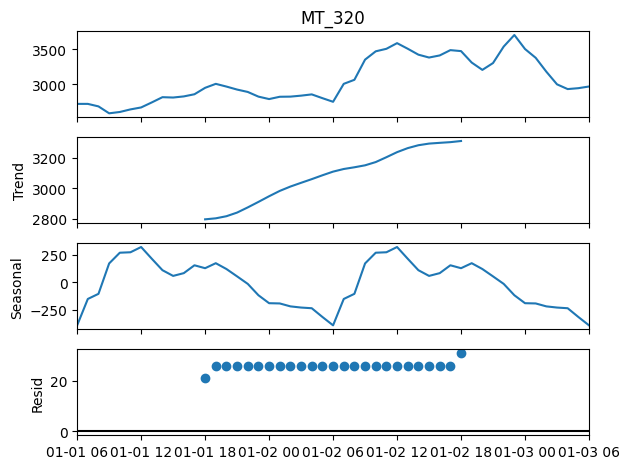

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(df_data['MT_320'][6:55], model="additive")
decomposition.plot()
plt.show()

In [14]:
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    ),
    index=True
)

In [4]:
df_data = pd.read_parquet(
    os.path.join(
        DATA_PATH,
        'clean_complete.parquet'
    )
)
df_data = df_data.iloc[:10000]
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    ),
    index=True
)